# Precision-Recall AUC Calculation: Naive vs. Vectorized Approaches

**Precision-Recall AUC (PR-AUC) Formula:**
$$
\text{PR-AUC} = \int_0^1 \text{Precision}(r) \, dr
$$

Where $\text{Precision}(r)$ is the precision at recall $r$. The area under the precision-recall curve is typically computed using the trapezoidal rule over the set of (recall, precision) points.

This notebook demonstrates how to compute the area under the Precision-Recall curve (PR-AUC) for binary classification. We implement two approaches: a naive loop-based method and a fully vectorized method. Explanations are provided before each code cell for clarity.

# Precision-Recall AUC Calculation: Naive vs. Vectorized Approaches

This notebook demonstrates how to compute the area under the Precision-Recall curve (PR-AUC) for binary classification. We implement two approaches: a naive loop-based method and a fully vectorized method. Explanations are provided before each code cell for clarity.

In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
def pr_auc_naive(true_labels, predicted_scores):
    """
    Compute PR-AUC using a naive, loop-based approach.
    Args:
        true_labels (np.ndarray): Binary ground truth labels (0 or 1).
        predicted_scores (np.ndarray): Model scores or probabilities.
    Returns:
        auc (float): Area under the precision-recall curve.
        precisions (np.ndarray): Precision values at each threshold.
        recalls (np.ndarray): Recall values at each threshold.
    """
    # Sort scores and corresponding true labels in descending order
    sorted_indices = np.argsort(-predicted_scores)
    sorted_labels = true_labels[sorted_indices]
    # sorted_scores = predicted_scores[sorted_indices]

    precisions = []
    recalls = []

    true_positives = 0
    false_positives = 0
    total_positives = np.sum(sorted_labels)

    for i in range(len(sorted_labels)):
        if sorted_labels[i] == 1:
            true_positives += 1
        else:
            false_positives += 1

        precision = true_positives / (true_positives + false_positives)
        recall = true_positives / total_positives
        precisions.append(precision)
        recalls.append(recall)

    # Compute AUC using trapezoidal rule
    precisions = np.array(precisions)
    recalls = np.array(recalls)
    auc = np.trapezoid(precisions, recalls)

    return auc, precisions, recalls

## Step 1: Import Libraries and Define Naive PR-AUC Function

We first import NumPy and define a function to compute the PR-AUC using a straightforward, loop-based approach. This function sorts the predictions, iterates through the data, and calculates precision and recall at each threshold.

In [9]:
def pr_auc_vectorized(true_labels, predicted_scores):
    """
    Compute PR-AUC using a fully vectorized approach.
    Args:
        true_labels (np.ndarray): Binary ground truth labels (0 or 1).
        predicted_scores (np.ndarray): Model scores or probabilities.
    Returns:
        auc (float): Area under the precision-recall curve.
        precisions (np.ndarray): Precision values at each threshold.
        recalls (np.ndarray): Recall values at each threshold.
    """
    # Sort by decreasing score
    sorted_indices = np.argsort(predicted_scores)[::-1]
    sorted_labels = true_labels[sorted_indices]

    # Cumulative True Positives and False Positives
    # Cumulative sum helps in finding results against different thresholds.
    # The crucial point: By sorting by decreasing score and taking cumulative sums, we're treating everything we've seen so far as "predicted positive".
    cumulative_tp = np.cumsum(sorted_labels)
    cumulative_fp = np.cumsum(1 - sorted_labels)

    # Precision and Recall
    precisions = cumulative_tp / (cumulative_tp + cumulative_fp)
    recalls = cumulative_tp / np.sum(sorted_labels)

    # Compute AUC using trapezoidal rule
    auc = np.trapezoid(precisions, recalls)

    return auc, precisions, recalls

## Step 2: Define Vectorized PR-AUC Function

Next, we define a vectorized implementation for PR-AUC. This approach leverages NumPy operations for efficient computation of cumulative true positives, false positives, precision, and recall.

Naive PR-AUC: 0.5694444444444444
Vectorized PR-AUC: 0.5694444444444444


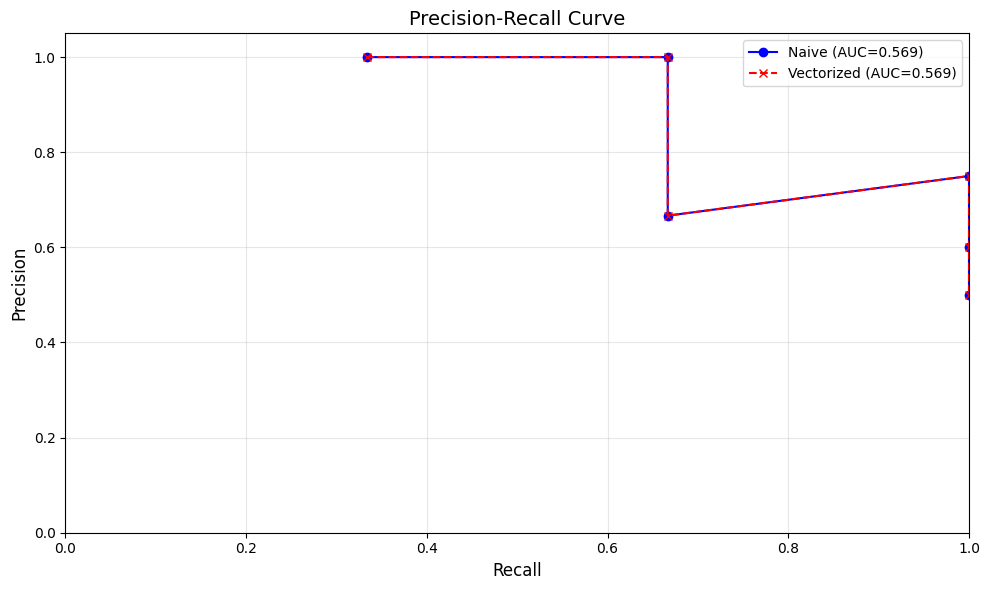

In [10]:

example_labels = np.array([0, 0, 1, 1, 0, 1])
example_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.2, 0.9])

# Compute PR-AUC using both methods
auc_naive, precisions_naive, recalls_naive = pr_auc_naive(example_labels, example_scores)
auc_vectorized, precisions_vectorized, recalls_vectorized = pr_auc_vectorized(example_labels, example_scores)

print("Naive PR-AUC:", auc_naive)
print("Vectorized PR-AUC:", auc_vectorized)

# Plot the PR curve
plt.figure(figsize=(10, 6))

# Plot both methods (they should overlap)
plt.plot(recalls_naive, precisions_naive, 'b-o', label=f'Naive (AUC={auc_naive:.3f})', markersize=6)
plt.plot(recalls_vectorized, precisions_vectorized, 'r--x', label=f'Vectorized (AUC={auc_vectorized:.3f})', markersize=6)

# Formatting
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.tight_layout()
plt.show()